<a href="https://colab.research.google.com/github/OgunbanjoT/Lab2AI/blob/main/AI_ssignment7_Toyin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- Imports ---
# ==========================================
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# --- Data Collection and Loading ---
# ==========================================
# TODO: Load the 'Boston Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Fetching via openml to avoid deprecation issues with load_boston()
boston = fetch_openml(name="boston", version=1, as_frame=True, parser="auto")

# Combine features and target into a single DataFrame
df = boston.frame
df.rename(columns={'MEDV': 'MEDV'}, inplace=True)

In [4]:
# --- Quick Check of Data ---
# ==========================================
# TODO: Display the first few rows of the dataset to understand its structure.
print("--- First 5 Rows of the Dataset ---")
print(df.head())
print("\n" + "="*50 + "\n")

--- First 5 Rows of the Dataset ---
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  




In [5]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
print("--- Data Info ---")
print(df.info())
print("\n--- Data Summary Statistics ---")
print(df.describe())
print("\n" + "="*50 + "\n")

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB
None

--- Data Summary Statistics ---
             CRIM          ZN       INDUS         NOX          RM         AGE  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000  

--- Missing Values Count ---
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64




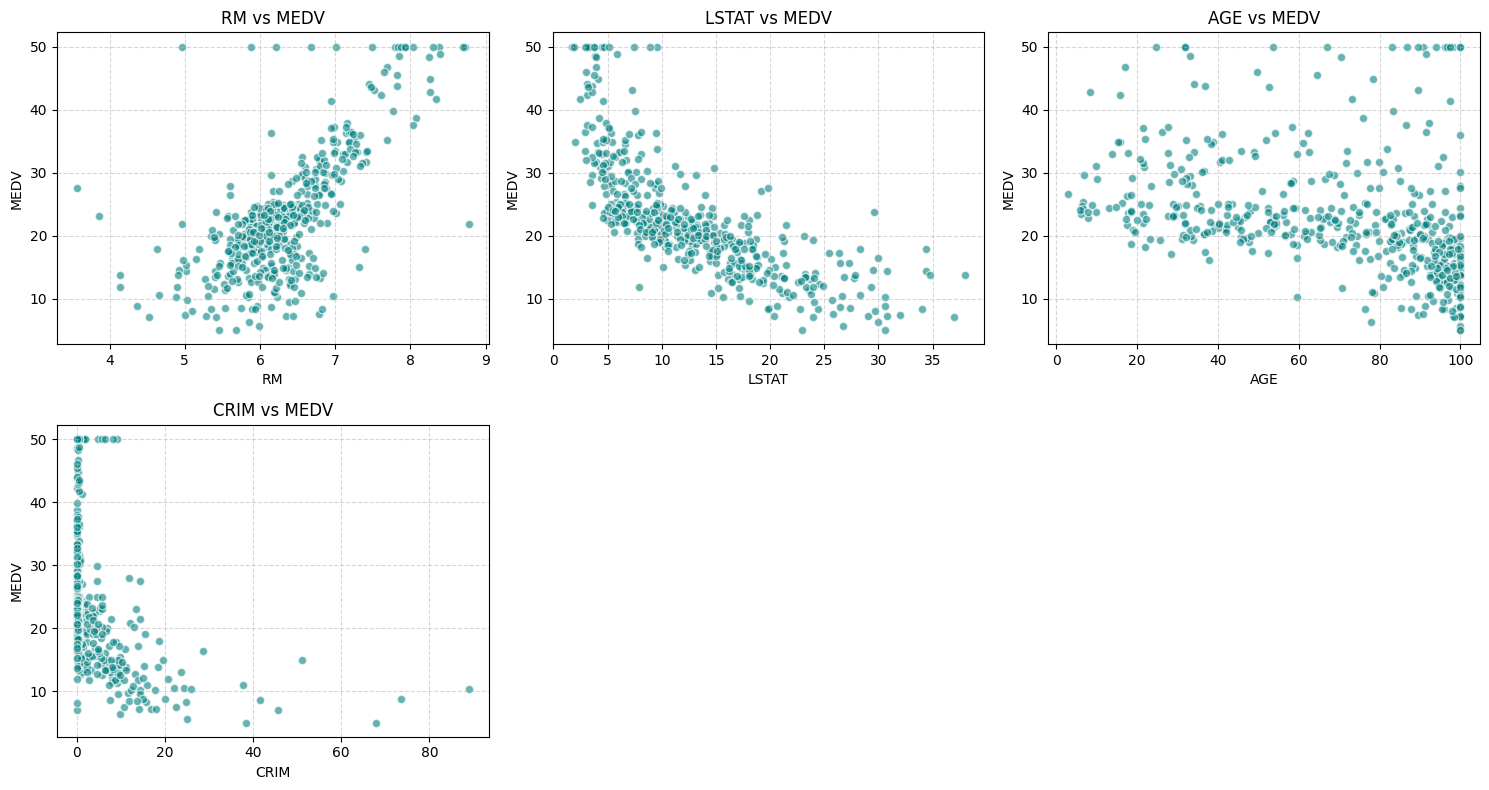

In [7]:
# --- EDA and Data Preprocessing ---
# ==========================================
# TODO: Check for missing/null values.
print("--- Missing Values Count ---")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# TODO: Create a function to automate scatter plots for all features vs the target variable.
def plot_scatter(dataframe, features, target):
    """
    Automates scatter plots for a list of features against a target variable.
    """
    num_features = len(features)
    plt.figure(figsize=(15, 4 * ((num_features + 2) // 3)))

    for i, feature in enumerate(features):
        plt.subplot(((num_features + 2) // 3), 3, i + 1)
        plt.scatter(dataframe[feature], dataframe[target], alpha=0.6, color='teal', edgecolors='w')
        plt.title(f'{feature} vs {target}')
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# TODO: Use the function to visualize the relationships between multiple features and the target variable.
selected_features = ['RM', 'LSTAT', 'AGE', 'CRIM']
plot_scatter(df, selected_features, 'MEDV')

In [8]:
# --- ML Model Training ---
# ==========================================
# Define X (features) and y (target)
X = df.drop(columns=['MEDV'])
y = df['MEDV']

# Convert categorical columns if any (e.g., CHAS might be fetched as category)
X = X.astype(float)

# TODO: Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Choose an appropriate regression model: Decision Tree or Random Forest.
# Selecting RandomForestRegressor for better accuracy and stability over a single Decision Tree.
rf_model = RandomForestRegressor(random_state=42)

# TODO: Train the model on the training data.
rf_model.fit(X_train, y_train)
print("Initial baseline model training complete.\n")

Initial baseline model training complete.



In [9]:
# --- Model Evaluation & Tuning ---
# ==========================================
# TODO: Evaluate performance on the test set & perform parameter tuning to improve results.
# Let's perform Grid Search CV for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

print("Running Hyperparameter Tuning using GridSearchCV...")
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Use the best model found
best_model = grid_search.best_estimator_
print(f"Best Parameters found: {grid_search.best_params_}\n")

# Predict on the test set
y_pred = best_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")
print("\n" + "="*50 + "\n")

Running Hyperparameter Tuning using GridSearchCV...
Best Parameters found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

--- Model Performance Metrics ---
Root Mean Squared Error (RMSE): 2.8110
R-squared Score (R²): 0.8923




In [10]:
# --- Model Prediction ---
# ==========================================
# TODO: Predict house prices from a new set of feature inputs.
# Example data matching the prompt specifications
new_data = pd.DataFrame([{
    'CRIM': 0.2, 'ZN': 12.5, 'INDUS': 7.07, 'CHAS': 0.0, 'NOX': 0.5,
    'RM': 6.5, 'AGE': 68.0, 'DIS': 4.0, 'RAD': 2.0, 'TAX': 250.0,
    'PTRATIO': 17.0, 'B': 400.0, 'LSTAT': 12.0
}])

# Ensure the columns match the training features order precisely
new_data = new_data[X.columns]

# Predict
predicted_price = best_model.predict(new_data)
print(f"Predicted House Price for the new feature input: ${predicted_price[0] * 1000:.2f}")

Predicted House Price for the new feature input: $22189.00


Key Takeaways for Report

Data Types: Features like CHAS are categorical indicators (0 or 1), while features like RM (rooms) and LSTAT (lower status percentage) are continuous variables.

EDA Insights: RM typically shows a strong positive linear relationship with the target variable MEDV, while LSTAT shows a negative non-linear relationship.

Model Selection: Random Forest is selected over a single Decision Tree because it acts as an ensemble approach, drastically lowering variance and protecting the model from overfitting.